# Measure correlation dimension of jets with Omnifold measurement

This notebook implements a measurement of the correlation dimension of a sample of jets isolated from the ATLAS Omnifold Z+jets measurement. This involves the following:

1. Cluster jets and isolate a randomly skimmed selection of jets within a pT bin (default 330 to 370 GeV) using every event sample needed to build the measurement.
2. Calculate the EMD between every jet in this selection. For computational reasons, we limit to 50k jets per event sample in the analysis.
3. Bin the EMDs with the weight sets provided by Omnifold
4. Plot the results

These four steps are performed first for the pseudo-data measurement, and second for the data measurement. Given the analysis is somewhat complicated and compute intensive, this notebook will take a long time to run even with resources that can run the calculations in parallel. In particular binning the EMDs with all necessary weight sets can take up to an hour on one Perlmutter CPU node.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import glob
import pickle
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import fastjet as fj

import utils
import visualize as vis

In [ ]:
# Get ROOT TTrees and pass 190 flags
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_May19_MGPy8FxFxPlusNonStrong_withdd_Test_23Nov25_shuffled.root"
)
t = f["OmniTree"]
truth_pass190 = ak.to_numpy(t["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
)
t_pd = f_pd["OmniTree"]
truth_pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())
truth_pT_ll_pd = ak.to_numpy(t_pd["truth_pT_ll"].array())
truth_pass200_pd = np.logical_and(truth_pass190_pd, truth_pT_ll_pd > 200)

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5_shuffled.root"
)
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190_hv, truth_pT_ll_hv > 200)

f_sherpa = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_30Jul2025_Sherpa2211PlusNonStrong_8Dec25_shuffled.root"
)
t_sherpa = f_sherpa["OmniTree"]
truth_pass190_sherpa = ak.to_numpy(t_sherpa["truth_pass190"].array())
truth_pT_ll_sherpa = ak.to_numpy(t_sherpa["truth_pT_ll"].array())
truth_pass200_sherpa = np.logical_and(truth_pass190_sherpa, truth_pT_ll_sherpa > 200)

In [ ]:
# Load event weights for the Sherpa and MadGraph predictions
mg_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/madgraph_weights.npz")
sherpa_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/sherpa_weights.npz")

## Calculate EMDs

In [ ]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 330.0
ptmax = 370.0
etamax = 1.2
max_jets = 50000

# Maximum events to read from each file (avoids uproot int32 overflow on large jagged arrays)
MAX_EVENTS = 10_000_000

# Set location for EMD storage, set to None to not save
emd_dir = "./emd_storage"
if not os.path.exists(emd_dir) and emd_dir is not None:
    os.makedirs(emd_dir)

In [ ]:
# Calculate EMDs for truth MC
utils.calculate_emds_from_file(
    t,
    truth_pass200[:MAX_EVENTS],
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_330to370.npz",
)

In [ ]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    t_pd,
    truth_pass200_pd[:MAX_EVENTS],
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_pd_330to370.npz",
)

In [ ]:
# Calculate EMDs for HV MC
utils.calculate_emds_from_file(
    t_hv,
    truth_pass200_hv[:MAX_EVENTS],
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_hv_330to370.npz",
)

In [ ]:
# Calculate EMDs for Sherpa
utils.calculate_emds_from_file(
    t_sherpa,
    truth_pass200_sherpa[:MAX_EVENTS],
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_sherpa_330to370.npz",
)

## Measurement with Pseudodata

### Histogramming

In [ ]:
# Load all weights from the Omnifold pseudodata measurement
of_pseudodata = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="weights",
    mode="r",
)
of_pseudodata_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="hv_weights",
    mode="r",
)

In [ ]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
nominal_emds = "./emd_storage/truth_mc_330to370.npz"
truthpd_emds = "./emd_storage/truth_pd_330to370.npz"
hv_emds = "./emd_storage/truth_hv_330to370.npz"

n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [
    name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name
]
mcbootstrap_weights = [
    name for name in of_pseudodata.keys() if "weights_bootstrap_mc_" in name
]
nominal_weights = {
    "prior": mg_weights["nominal"][truth_pass200 == 1],
    "nominal": of_pseudodata["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{
        f"ensemble_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(n_init_weights)
    },
    **{
        f"bootstrap_data_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(dbootstrap_weights)
    },
    **{
        f"bootstrap_mc_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(mcbootstrap_weights)
    },
    "trackEffMain": of_pseudodata["weights_trackEffMain"].to_numpy()[
        truth_pass200 == 1
    ],
    "trackEffJet": of_pseudodata["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_pseudodata["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"].to_numpy()[
        truth_pass200 == 1
    ],
    "muCalID": of_pseudodata["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_pseudodata["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_pseudodata["weights_muCalResBias"].to_numpy()[
        truth_pass200 == 1
    ],
    "muCalScale": of_pseudodata["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_pseudodata["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_pseudodata["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_pseudodata["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_pseudodata["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_pseudodata["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_pseudodata["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_pseudodata["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_pseudodata["target_dd"].to_numpy()[truth_pass200 == 1],
}
truthpd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[truth_pass200_pd == 1],
}
hv_weights = {
    "hv": of_pseudodata_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}

In [ ]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(120), 25)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins, n_jobs=-1
)
truthpd_hists = utils.calculate_correlation_dimension_from_file(
    truthpd_emds, truthpd_weights, bins, n_jobs=-1
)
hv_hists = utils.calculate_correlation_dimension_from_file(
    hv_emds, hv_weights, bins, n_jobs=-1
)

all_hists = {
    **nominal_hists,
    **truthpd_hists,
    **hv_hists,
}

In [ ]:
# Pickle the histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)
with open(os.path.join(hist_dir, "pd_hists_330to370.pkl"), "wb") as f:
    pickle.dump(all_hists, f)

### Plotting

In [24]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "pd_hists_330to370.pkl"), "rb") as f:
    all_hists = pickle.load(f)

In [25]:
renamed_hists = {}
for key, item in all_hists.items():
    if "muon" in key:
        renamed_hists["mu" + key.split("muon")[1]] = item
    else:
        renamed_hists[key] = item
all_hists = renamed_hists

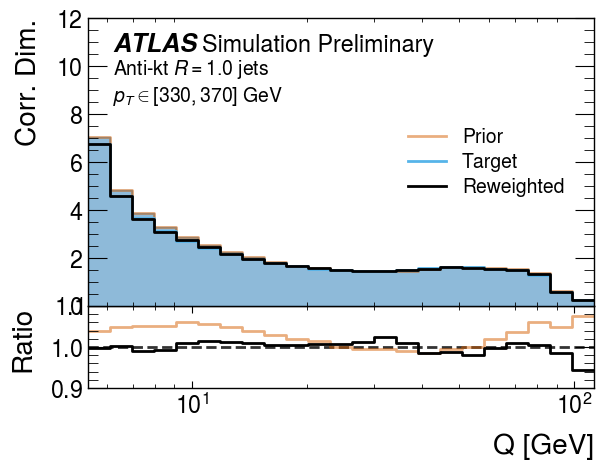

In [26]:
# Plot comparison to truth pseudodata (no uncertainties)\
import visualize as vis

comp = vis.compare_to_target(
    all_hists,
    log_xscale=True,
    linear_yscale=True,
    ylim=(0, 12),
    rlim=(0.9, 1.1),
    ylabel="Corr. Dim.",
    xlabel="Q [GeV]",
)

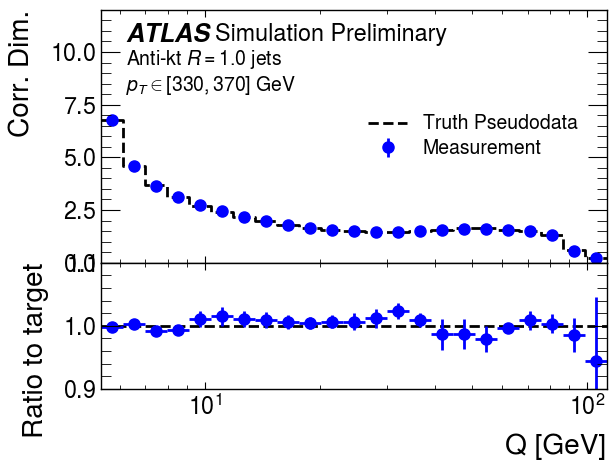

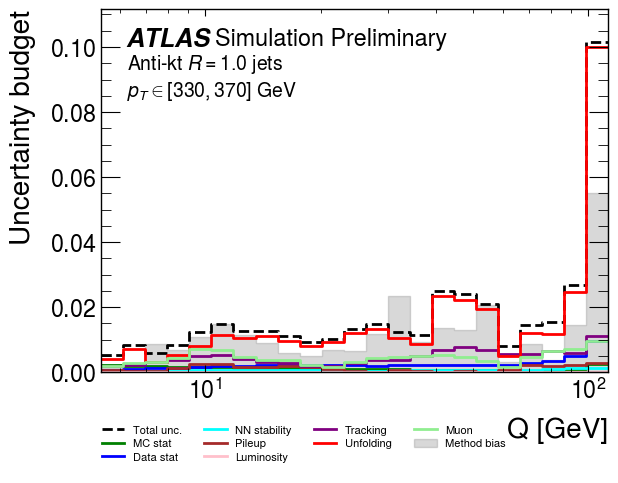

In [31]:
# Plot pseudo-measurement and uncertainty budget
import visualize as vis

xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    figsize=(6.4, 4.8),
    color="blue",
    linear_yscale=True,
    data=False
)
xsec.show()
budget.show()

## Measurement with data

### Histogramming

In [ ]:
# Load all weights from the Omnifold data measurement
of_data = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="weights",
    mode="r",
)
of_data_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="hv_weights",
    mode="r",
)

In [ ]:
# Create dictionary describing all of the histograms needed for the data measurement
n_init_weights = [name for name in of_data.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [
    name for name in of_data.keys() if "weights_bootstrap_data_" in name
]
mcbootstrap_weights = [
    name for name in of_data.keys() if "weights_bootstrap_mc_" in name
]
truth_mc_weights = {
    "nominal": of_data["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{
        f"ensemble_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(n_init_weights)
    },
    **{
        f"bootstrap_data_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(dbootstrap_weights)
    },
    **{
        f"bootstrap_mc_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(mcbootstrap_weights)
    },
    "trackEffMain": of_data["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_data["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_data["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_data["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_data["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_data["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_data["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_data["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_data["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_data["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_data["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_data["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_data["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_data["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_data["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_data["target_dd"].to_numpy()[truth_pass200 == 1],
}
hv_weights = {
    "hv": of_data_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}
truth_madgraph_weights = {
    "madgraph": mg_weights["nominal"][truth_pass200 == 1],
    "weights_theoryQCD": mg_weights["weights_theoryQCD"][truth_pass200 == 1],
    "weights_theoryPDF": mg_weights["weights_theoryPDF"][truth_pass200 == 1],
    "weights_theoryAlphaS": mg_weights["weights_theoryAlphaS"][truth_pass200 == 1],
    "weights_theoryPSsoft": mg_weights["weights_theoryPSsoft"][truth_pass200 == 1],
    "weights_theoryPSjet": mg_weights["weights_theoryPSjet"][truth_pass200 == 1],
    "weights_theoryPSscale": mg_weights["weights_theoryPSscale"][truth_pass200 == 1],
    "weights_theoryMPI": mg_weights["weights_theoryMPI"][truth_pass200 == 1],
}
truth_sherpa_weights = {
    "sherpa": sherpa_weights["nominal"][truth_pass200_sherpa == 1],
    "weights_theoryQCD": sherpa_weights["weights_theoryQCD"][truth_pass200_sherpa == 1],
    "weights_theoryPDF": sherpa_weights["weights_theoryPDF"][truth_pass200_sherpa == 1],
    "weights_theoryAlphaS": sherpa_weights["weights_theoryAlphaS"][
        truth_pass200_sherpa == 1
    ],
}

In [ ]:
# Set paths to EMDs needed for the data measurement
truth_mc_emds = "./emd_storage/truth_mc_330to370.npz"
truth_hv_emds = "./emd_storage/truth_hv_330to370.npz"
truth_sherpa_emds = "./emd_storage/truth_sherpa_330to370.npz"

In [ ]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(120), 25)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    truth_mc_emds, truth_mc_weights, bins, n_jobs=-1
)
hv_hists = utils.calculate_correlation_dimension_from_file(
    truth_hv_emds, hv_weights, bins
)
madgraph_hists = utils.calculate_correlation_dimension_from_file(
    truth_mc_emds, truth_madgraph_weights, bins
)
sherpa_hists = utils.calculate_correlation_dimension_from_file(
    truth_sherpa_emds, truth_sherpa_weights, bins
)

all_hists = {
    **nominal_hists,
    **hv_hists,
    **madgraph_hists,
    **sherpa_hists,
}

In [ ]:
# Pickle the histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)
with open(os.path.join(hist_dir, "data_hists_330to370.pkl"), "wb") as f:
    pickle.dump(all_hists, f)

### Plotting

In [20]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "data_hists_330to370.pkl"), "rb") as f:
    all_hists = pickle.load(f)

In [21]:
renamed_hists = {}
for key, item in all_hists.items():
    if "muon" in key:
        renamed_hists["mu" + key.split("muon")[1]] = item
    else:
        renamed_hists[key] = item
all_hists = renamed_hists

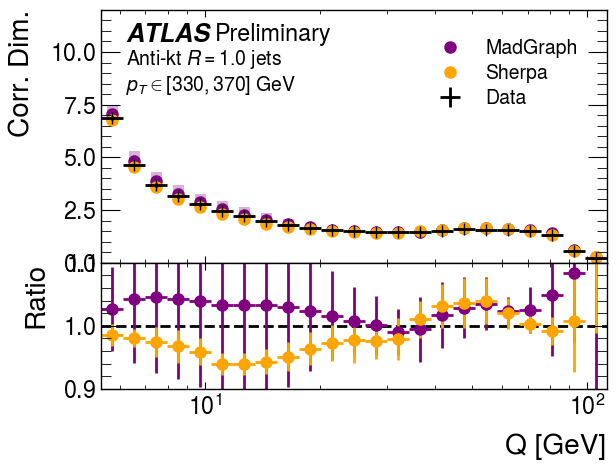

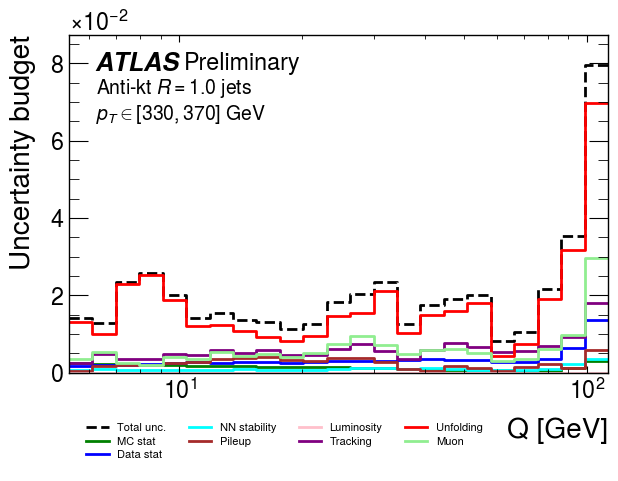

In [23]:
# Plot data measurement and uncertainty budget
import visualize as vis

xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    measured_label="Data",
    target_key="madgraph",
    target_label="MadGraph",
    target2_key="sherpa",
    target2_label="Sherpa",
    data_measurement_mode=True,
    color="black",
    linear_yscale=True,
    ylim=(0, 12),
    rlim=(0.9, 1.1),
)
xsec.show()
budget.show()